# Prepared Data Workflow — Interpretable Model Inputs

This notebook turns joined trajectory-metric exports into a cleaned, modelling-ready dataset for the downstream GAM and XGBoost notebooks.<br>
**Workflow summary:** import analysis tools, load the joined CSV, inspect distributions and dependency structure, remove redundant features, decide on target scaling, then export the prepared table.


## 1. Imports and Configuration
**Purpose:** Load the analysis libraries used to inspect feature quality and prepare the final modelling table.<br>
**Inputs:** Python plotting/statistics libraries available in the environment.<br>
**Outputs:** imported utilities ready for the remaining preparation workflow.<br>
**How to Verify:** the import cell should execute without missing-package errors before any dataset-specific assumptions are made.


In [1]:
# Imports are grouped here so each later section can focus on one verification question
# rather than on package setup details.
# Core libraries
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib

# Compatibility shim: matplotlib_inline expects RcParams._get in some versions.
if not hasattr(matplotlib.RcParams, "_get"):
    matplotlib.RcParams._get = matplotlib.RcParams.__getitem__

import matplotlib.pyplot as plt
import seaborn as sns

# Distribution checks
from scipy import stats
from scipy.stats import skew

# Preprocessing and evaluation
from sklearn.feature_selection import mutual_info_regression


# Settings
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("All libraries imported successfully.")


All libraries imported successfully.


## 2. Load and Inspect the Dataset
**Purpose:** Load the joined trajectory-metric CSV, inspect its schema, and identify the candidate target/features before any transformations.<br>
**Inputs:** run-scoped joined metrics CSV path and the expected trajectory-level columns.<br>
**Outputs:** raw dataframe, dataset info, summary statistics, resolved target column, and the initial numerical feature list.<br>
**How to Verify:** confirm the printed run/path, dataset shape, missing-value summary, selected `target_col`, and detected numerical features before proceeding.


In [2]:
# Keep the input and export paths run-scoped so the prepared dataset can be traced back
# to the exact trajectory-metric export that produced it.
# ── Configure paths ──────────────────────────────────────────────────────────
# Adjust this path to point to your eval_epoch CSV
RUN_NAME = "nusc_mini_debug_tpp-11_Mar_2026_15_29_02"
print(f'Run: {RUN_NAME}')
CSV_PATH = Path("../../results/trajectory_prediction/trajectory_metrics_joined/"
                f"{RUN_NAME}/eval_epoch_5.csv")

SAVE_DIR = Path("../../results/interpretable_model/gam") / RUN_NAME / "plots"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Load the dataset
df = pd.read_csv(CSV_PATH)
# Load the joined metrics once and reuse the same dataframe throughout the notebook so
# every verification plot refers to the same underlying rows.

print(f"Dataset shape: {df.shape}")
print(f"\n{'='*60}")
print("First 5 rows:")
df.head()


Run: nusc_mini_debug_tpp-11_Mar_2026_15_29_02
Dataset shape: (451, 44)

First 5 rows:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
0,329,0.914857,3.197555,0.915371,2.867357,10.152276,0.962106,1.230403,0.116722,0.056417,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
1,190,0.151084,0.312564,0.087302,-1.594040,-1.285830,0.085898,0.218477,0.063105,0.007725,...,1160.377375,40.869190,28.392473,0.014650,0.005171,0.009480,NaN,NaN,NaN,NaN
2,420,0.475158,0.833887,0.426153,3.946011,5.647027,0.218623,0.383437,0.099171,0.031384,...,1821.083675,44.533135,40.892780,0.027456,0.012630,0.010433,NaN,NaN,8.0,0.004393
3,131,1.275023,3.326790,0.769307,2.154090,7.083624,1.233457,1.483624,0.190256,0.051802,...,1230.401053,43.391608,28.355738,0.013004,0.005689,0.007315,NaN,NaN,NaN,NaN
4,191,0.172736,0.389740,0.078058,-1.785440,-0.578248,0.091226,0.218477,0.064457,0.010995,...,1057.088774,37.340273,28.309616,0.014190,0.005676,0.008514,NaN,NaN,NaN,NaN


In [3]:
# Inspect schema and missingness before selecting features; otherwise later drops or
# dtype-related failures would hide whether the raw export itself violated assumptions.
# Data types and missing values
print("Dataset Info:")
print(f"{'='*60}")
df.info()
print(f"\n{'='*60}")
print(f"\nMissing values per column:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 44 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   data_idx                  451 non-null    int64  
 1   ml_ade                    451 non-null    float64
 2   ml_fde                    451 non-null    float64
 3   min_ade_5                 451 non-null    float64
 4   nll_mean                  451 non-null    float64
 5   nll_final                 451 non-null    float64
 6   mean_speed                451 non-null    float64
 7   max_speed                 451 non-null    float64
 8   std_speed                 451 non-null    float64
 9   mean_acceleration         451 non-null    float64
 10  max_acceleration          451 non-null    float64
 11  mean_jerk                 451 non-null    float64
 12  max_jerk                  451 non-null    float64
 13  duration                  451 non-null    float64
 

In [4]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,data_idx,ml_ade,ml_fde,min_ade_5,nll_mean,nll_final,mean_speed,max_speed,std_speed,mean_acceleration,...,scene_bbox_area,scene_bbox_width,scene_bbox_height,scene_spatial_density,scene_density_VEHICLE,scene_density_PEDESTRIAN,scene_num_BICYCLE,scene_density_BICYCLE,scene_num_MOTORCYCLE,scene_density_MOTORCYCLE
count,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,...,451.000000,451.000000,451.000000,451.000000,451.000000,451.000000,30.0,30.000000,67.000000,67.000000
mean,225.000000,0.795241,1.714137,0.651478,1.615489,4.358871,1.047268,1.255228,0.139951,0.013555,...,1370.663233,40.175802,33.639475,0.017466,0.005686,0.011310,2.0,0.001196,5.000000,0.002631
std,130.336743,0.582555,1.354286,0.568139,2.628688,4.216529,0.476805,0.503591,0.104514,0.047515,...,459.222736,5.788054,8.415139,0.004751,0.002103,0.005078,0.0,0.000032,2.443296,0.001281
min,0.000000,0.029572,0.042517,0.024698,-3.505121,-2.427706,0.000000,0.000000,0.000000,-0.202674,...,776.025388,26.965117,23.491130,0.009868,0.002880,0.003920,2.0,0.001164,2.000000,0.001164
25%,112.500000,0.353661,0.701191,0.246380,0.210995,2.004534,0.863279,1.230403,0.071290,-0.007716,...,1007.260160,36.739884,28.333285,0.013504,0.003866,0.007502,2.0,0.001164,3.000000,0.001684
50%,225.000000,0.671298,1.385031,0.506425,1.107724,3.378124,1.226409,1.395103,0.114736,0.005237,...,1187.889506,40.145465,28.803449,0.017126,0.005676,0.011641,2.0,0.001196,5.000000,0.002602
75%,337.500000,1.079434,2.312771,0.852741,2.484541,5.534409,1.363743,1.564261,0.183586,0.030841,...,1841.250853,44.443819,43.279501,0.021330,0.007284,0.015012,2.0,0.001227,8.000000,0.003539
max,450.000000,3.694747,7.312213,3.529320,14.007240,20.000000,1.627962,2.048388,0.582534,0.183462,...,2260.842272,51.971918,48.085698,0.036208,0.017735,0.021173,2.0,0.001227,8.000000,0.005912


In [5]:
# Resolve the target and candidate numerical features explicitly so later pruning and
# transformation steps can be verified against a fixed starting point.
# ── Define target and feature columns ─────────────────────────────────────────
# Target: trajectory prediction error metric
target_col = "ml_ade"  # Change to 'ml_fde', 'min_ade_5', etc. as needed

# Auto-detect from common target names if not found
potential_targets = [
    "ml_ade", "ml_fde", "min_ade_5", "min_fde_5",
    "ade", "fde", "minADE", "minFDE", "min_ade", "min_fde",
    "brier_fde", "nll", "miss_rate",
]
if target_col not in df.columns:
    for col in potential_targets:
        if col in df.columns:
            target_col = col
            break

assert target_col in df.columns, f"Target '{target_col}' not found. Available: {df.columns.tolist()}"
print(f"Target variable: {target_col}")

# Agent motion & scene context features
FEATURE_CANDIDATES = [
    # Agent motion features
    'mean_speed', 'max_speed', 'std_speed',
    'mean_acceleration', 'max_acceleration',
    'mean_jerk', 'max_jerk',
    # path_efficiency (displacement/path_length) is window-independent;
    # displacement and path_length are omitted — their scale information
    # is already captured by mean_speed.
    'path_efficiency',
    'heading_change', 'has_collision', 'min_neighbor_distance',
    # Per-second normalised variant: heading_change_per_sec gives angular rate
    # (deg/s), comparable across runs with different window lengths.
    # displacement and path_length are left unnormalised — they scale with
    # window length similarly to ADE, preserving the feature→target relationship.
    'heading_change_per_sec',
    # Scene context features
    'scene_num_agents', 'scene_num_VEHICLE',
    'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height',
    'scene_spatial_density', 'scene_density_VEHICLE',
]

# Model-setting columns: constant within a run, carried as metadata through the
# pipeline so downstream notebooks can filter or group by configuration.
MODEL_SETTING_COLS = ['attention_radius_m', 'history_sec', 'prediction_sec']

# Keep only features that actually exist in the data
numerical_cols = [c for c in FEATURE_CANDIDATES if c in df.columns and np.issubdtype(df[c].dtype, np.number)]
model_setting_cols = [c for c in MODEL_SETTING_COLS if c in df.columns]

# Identify any categorical columns among the features (e.g., agent type)
categorical_cols = [c for c in df.columns if df[c].dtype == 'object' or df[c].dtype.name == 'category']
# Exclude ID-like columns
exclude_patterns = ['instance', 'id', 'idx', 'name']
categorical_cols = [c for c in categorical_cols if not any(p in c.lower() for p in exclude_patterns)]

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Model setting cols ({len(model_setting_cols)}): {model_setting_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")


Target variable: ml_ade

Numerical features (20): ['mean_speed', 'max_speed', 'std_speed', 'mean_acceleration', 'max_acceleration', 'mean_jerk', 'max_jerk', 'path_efficiency', 'displacement', 'path_length', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_num_VEHICLE', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE']
Model setting cols (3): ['attention_radius_m', 'history_sec', 'prediction_sec']
Categorical features (2): ['agent_type', 'scene_path']


## 3. Check Distribution of Features and Target
**Purpose:** Assess marginal distributions and skewness so later transformation decisions are grounded in observed data shape.<br>
**Inputs:** raw dataframe, selected target column, and detected numerical feature columns.<br>
**Outputs:** target distribution plots, feature distribution grids, and a skewness summary table.<br>
**How to Verify:** confirm the target histogram/KDE and skewness table agree about whether the target is strongly right-skewed.


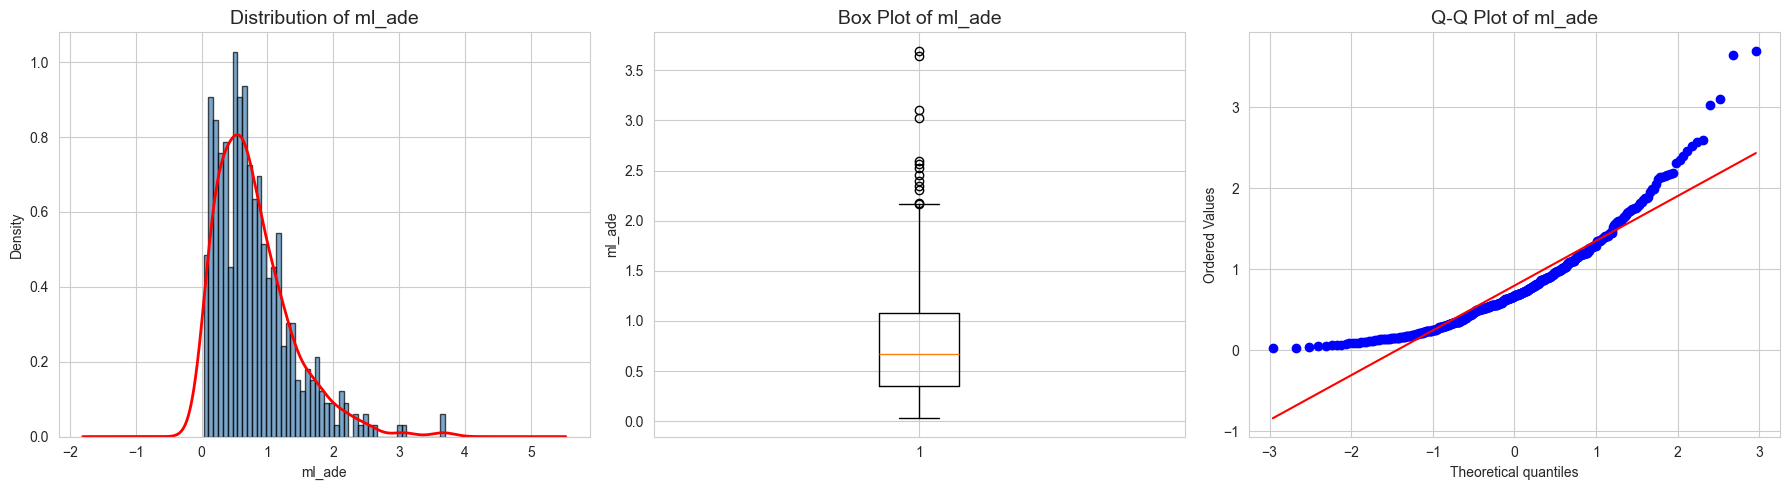


Target 'ml_ade' statistics:
  Skewness:  1.4600
  Kurtosis:  3.1145
  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.
    (Common for ADE/FDE — error distributions are typically right-skewed)


In [6]:
# Distribution of the target variable (prediction error metric)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram + KDE
axes[0].hist(df[target_col].dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
df[target_col].dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
axes[0].set_title(f"Distribution of {target_col}", fontsize=14)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel("Density")

# Box plot
axes[1].boxplot(df[target_col].dropna(), vert=True)
axes[1].set_title(f"Box Plot of {target_col}", fontsize=14)
axes[1].set_ylabel(target_col)

# Q-Q plot
stats.probplot(df[target_col].dropna(), dist="norm", plot=axes[2])
axes[2].set_title(f"Q-Q Plot of {target_col}", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / f"target_distribution_{target_col}.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis
target_skewness = skew(df[target_col].dropna())
target_kurtosis = stats.kurtosis(df[target_col].dropna())
print(f"\nTarget '{target_col}' statistics:")
print(f"  Skewness:  {target_skewness:.4f}")
print(f"  Kurtosis:  {target_kurtosis:.4f}")

if target_skewness > 1:
    print(f"  → Target is RIGHT-SKEWED (skewness > 1). Log transformation recommended.")
    print(f"    (Common for ADE/FDE — error distributions are typically right-skewed)")
elif target_skewness > 0.5:
    print(f"  → Target is MODERATELY right-skewed.")
else:
    print(f"  → Target is approximately symmetric.")

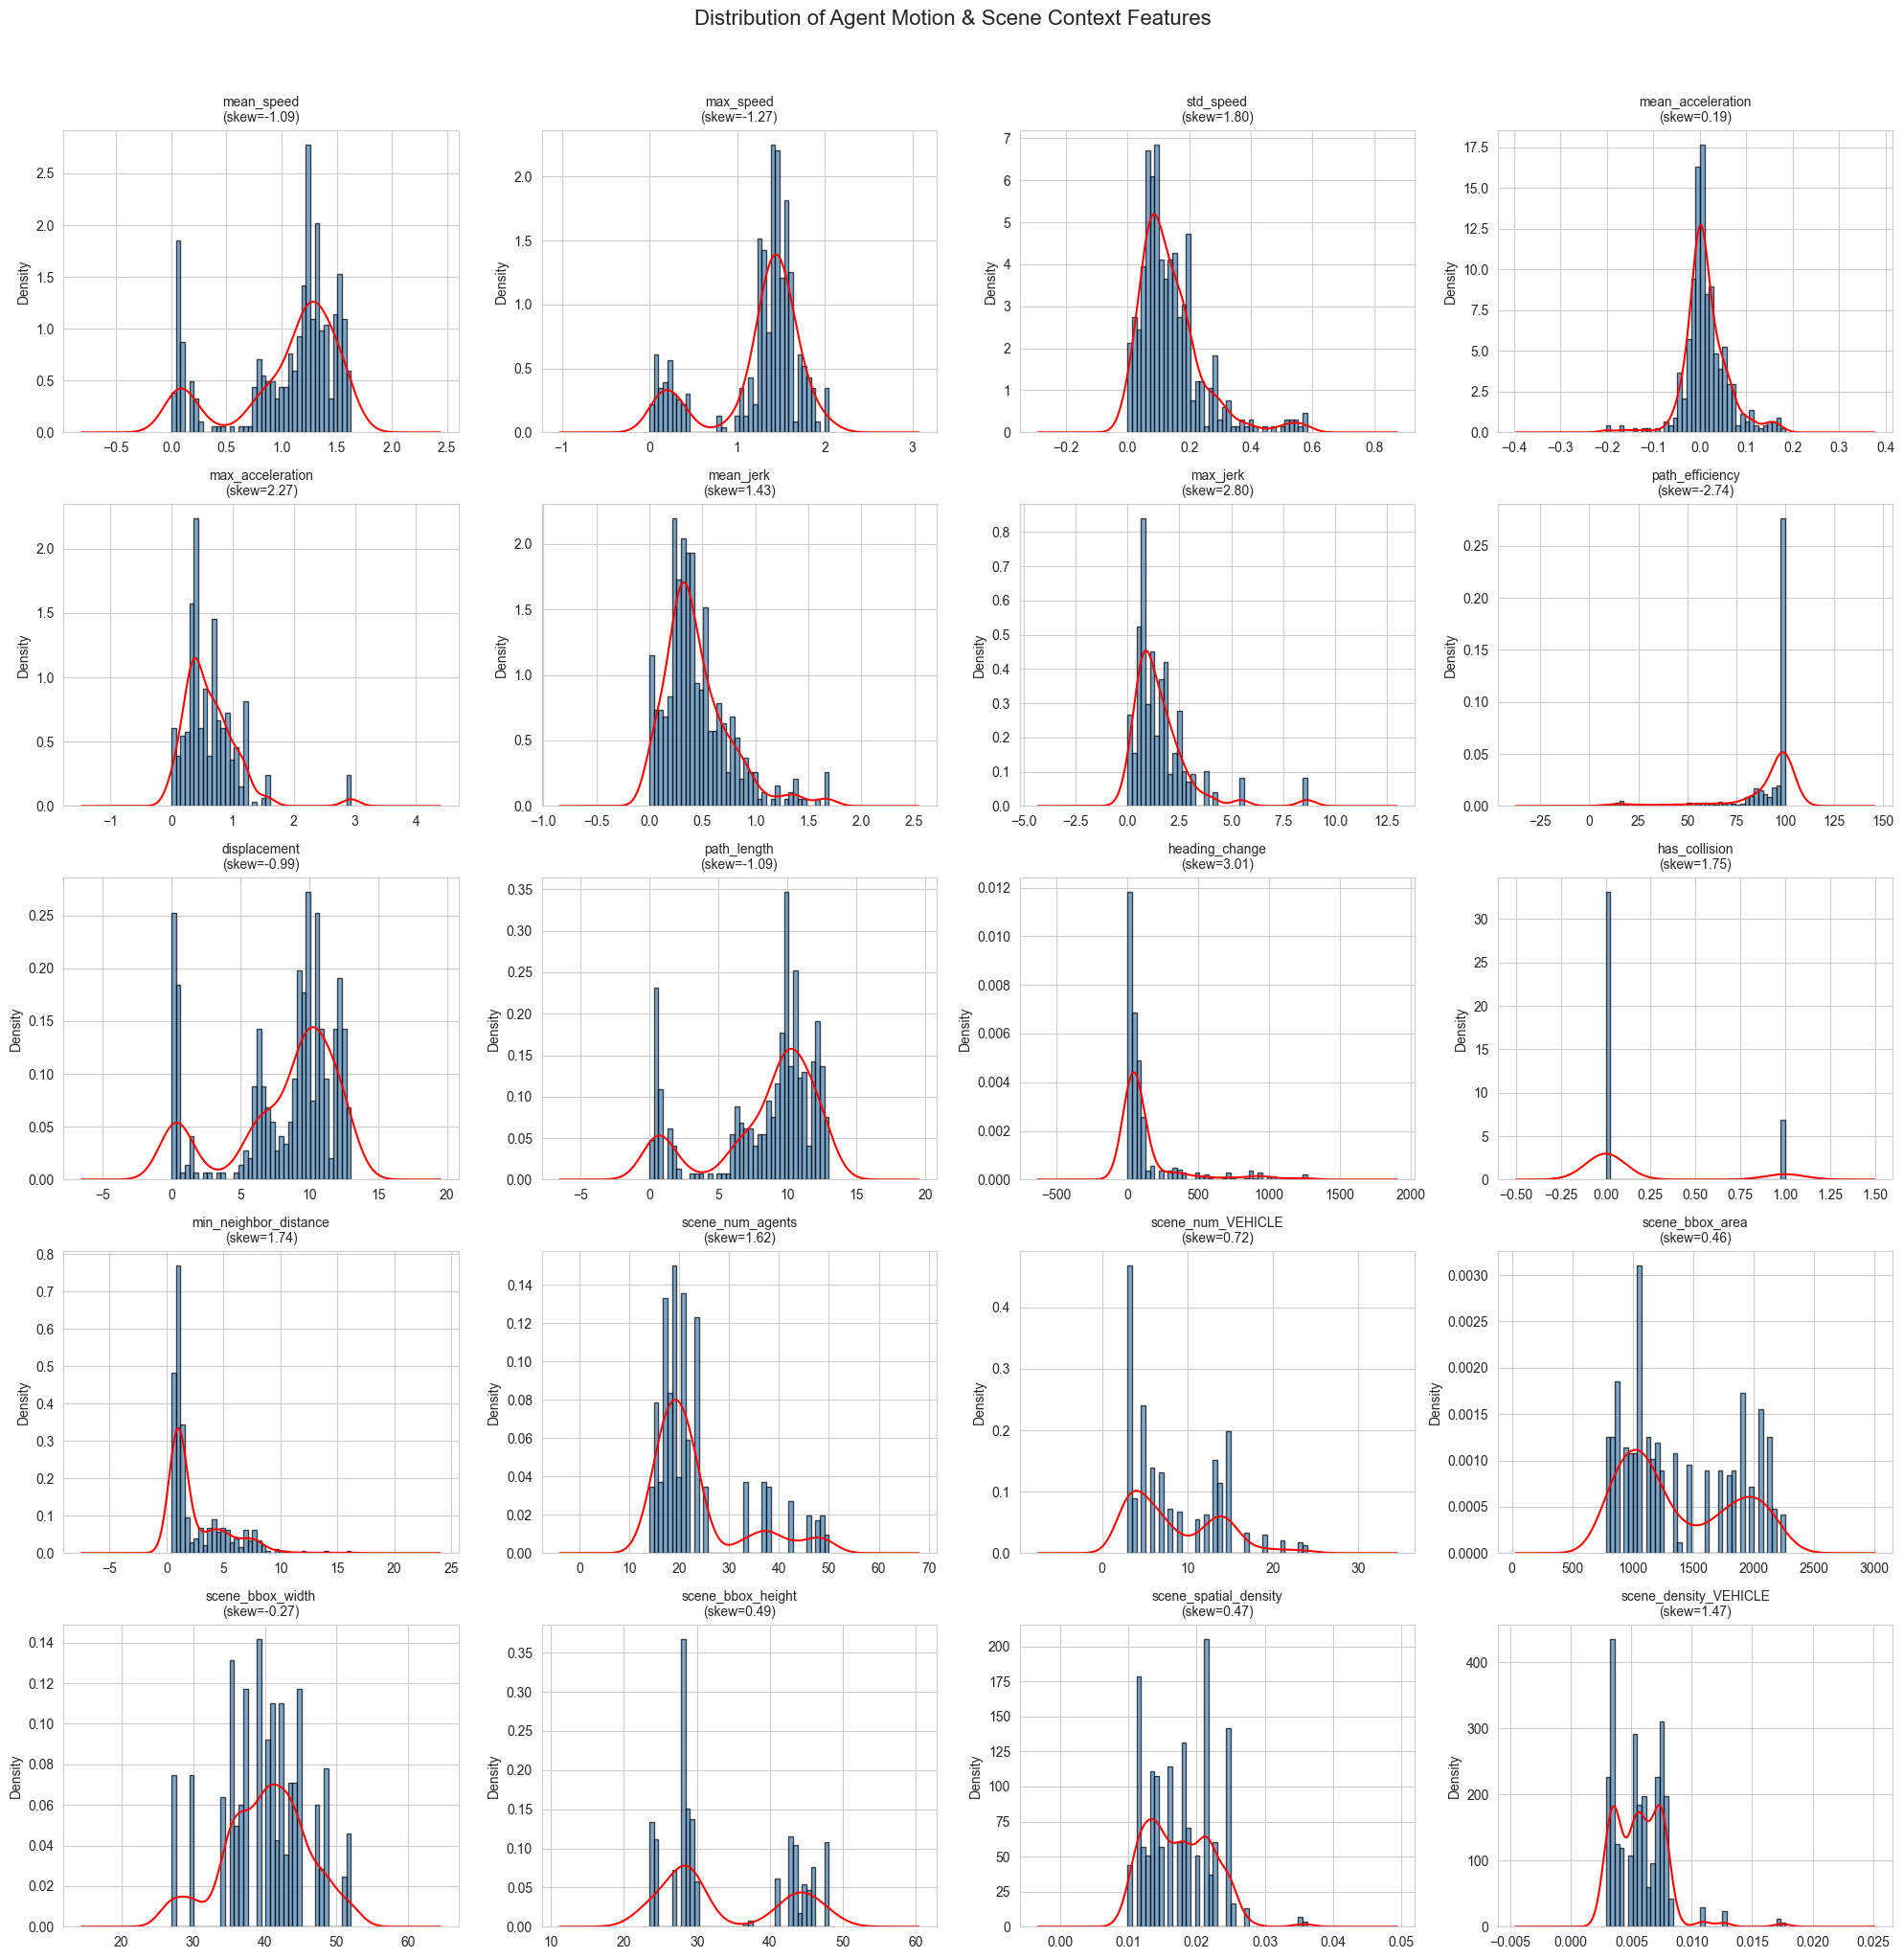

In [7]:
# Distribution of all numerical features
n_features = len(numerical_cols)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(5 * n_cols_plot, 4 * n_rows_plot))
axes = axes.flatten() if n_features > 1 else [axes]

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=40, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    df[col].dropna().plot.kde(ax=axes[i], color="red", linewidth=1.5)
    col_skew = skew(df[col].dropna())
    axes[i].set_title(f"{col}\n(skew={col_skew:.2f})", fontsize=10)
    axes[i].set_xlabel("")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Agent Motion & Scene Context Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Skewness summary table for all features and the target
skewness_df = pd.DataFrame({
    "Feature": numerical_cols + [target_col],
    "Skewness": [skew(df[c].dropna()) for c in numerical_cols + [target_col]],
    "Kurtosis": [stats.kurtosis(df[c].dropna()) for c in numerical_cols + [target_col]]
})
skewness_df["Skew Category"] = skewness_df["Skewness"].apply(
    lambda x: "Right-skewed" if x > 1 else ("Moderate" if x > 0.5 else ("Left-skewed" if x < -1 else "Symmetric"))
)
skewness_df = skewness_df.sort_values("Skewness", ascending=False).reset_index(drop=True)
print("Skewness Summary:")
skewness_df

Skewness Summary:


,Feature,Skewness,Kurtosis,Skew Category
0,heading_change,3.013466,8.802533,Right-skewed
1,max_jerk,2.798622,10.532398,Right-skewed
2,max_acceleration,2.272278,8.602435,Right-skewed
3,std_speed,1.803465,4.263631,Right-skewed
4,has_collision,1.750150,1.063025,Right-skewed
5,min_neighbor_distance,1.737306,3.199607,Right-skewed
6,scene_num_agents,1.619830,1.586252,Right-skewed
7,scene_density_VEHICLE,1.467618,5.765297,Right-skewed
8,ml_ade,1.460047,3.114523,Right-skewed
9,mean_jerk,1.429759,2.699040,Right-skewed


## 4. Static Trajectories Analysis
**Purpose:** Quantify how much of the dataset corresponds to stationary agents because that can explain extreme or degenerate metric behavior.<br>
**Inputs:** raw dataframe and the `mean_speed` column.<br>
**Outputs:** a static-agent indicator and summary counts/percentages for static trajectories.<br>
**How to Verify:** confirm `mean_speed` exists and that the reported static percentage is plausible for the selected run.


Static trajectory analysis (mean_speed == 0.0):
  Total trajectories: 451
  Static:             5 (1.1%)
  Moving:             446 (98.9%)


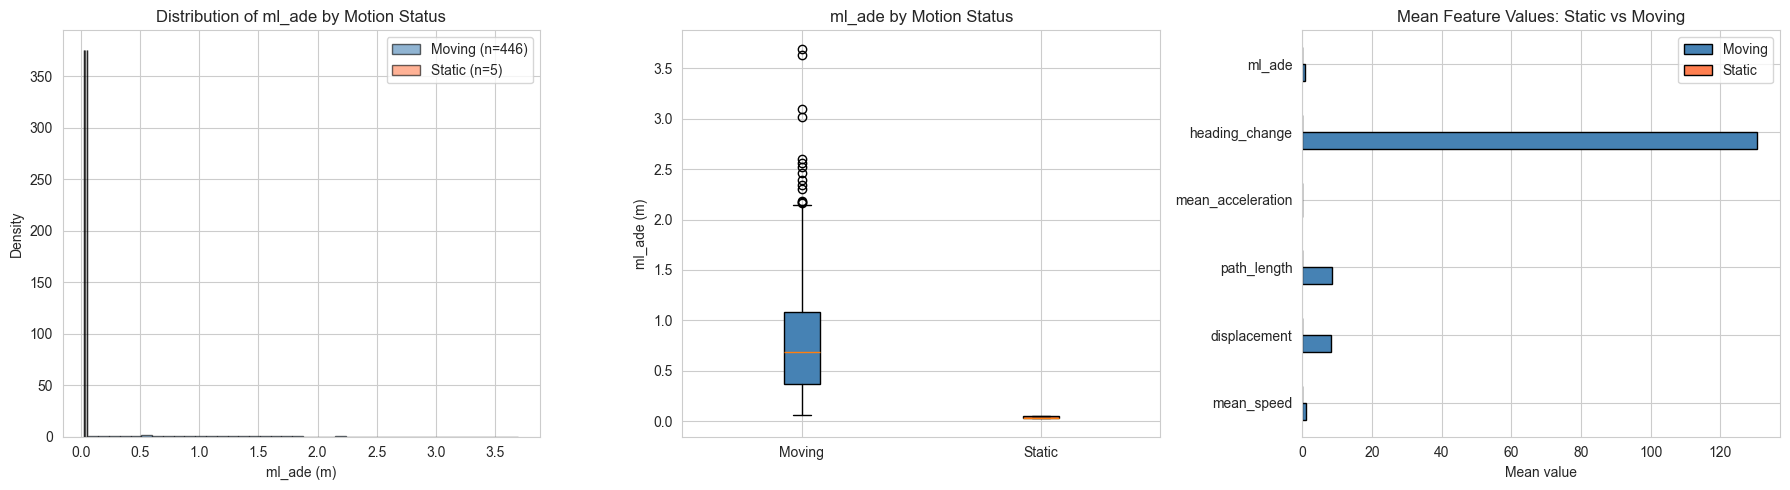


ml_ade summary by motion status:
           count    mean     std     min     25%     50%     75%     max
is_static                                                               
0          446.0  0.8037  0.5802  0.0573  0.3682  0.6809  1.0834  3.6947
1            5.0  0.0390  0.0106  0.0296  0.0310  0.0332  0.0503  0.0509

All feature means by motion status:


,Moving,Static,Ratio (Moving/Static)
mean_speed,1.0590,0.0000,NaN
max_speed,1.2693,0.0000,NaN
std_speed,0.1415,0.0000,NaN
mean_acceleration,0.0137,0.0000,NaN
max_acceleration,0.6440,0.0000,NaN
mean_jerk,0.4540,0.0000,NaN
max_jerk,1.5698,0.0000,NaN
path_efficiency,90.4989,100.0000,0.9050
displacement,8.2073,0.0000,NaN
path_length,8.4721,0.0000,NaN


In [9]:
# A zero-speed threshold is intentional here: the goal is to count truly stationary
# trajectories, not merely slow-moving ones that still express motion dynamics.
# ── Static trajectory analysis ───────────────────────────────────────────────
# Identify static agents (mean_speed == 0, i.e., parked/stationary vehicles)
STATIC_SPEED_THRESHOLD = 0.0  # exactly zero

if 'mean_speed' in df.columns:
    df['is_static'] = (df['mean_speed'] <= STATIC_SPEED_THRESHOLD).astype(int)
else:
    raise ValueError("'mean_speed' column not found — cannot determine static agents.")

n_static = df['is_static'].sum()
n_moving = len(df) - n_static
pct_static = 100 * n_static / len(df)

print(f"Static trajectory analysis (mean_speed == {STATIC_SPEED_THRESHOLD}):")
print(f"  Total trajectories: {len(df)}")
print(f"  Static:             {n_static} ({pct_static:.1f}%)")
print(f"  Moving:             {n_moving} ({100 - pct_static:.1f}%)")

# ── Compare prediction error: static vs moving ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overlaid histograms
for label, mask, color in [("Moving", df['is_static'] == 0, "steelblue"),
                            ("Static", df['is_static'] == 1, "coral")]:
    subset = df.loc[mask, target_col].dropna()
    if len(subset) > 0:
        axes[0].hist(subset, bins=40, density=True, alpha=0.6, color=color,
                     edgecolor="black", label=f"{label} (n={len(subset)})")
axes[0].set_xlabel(f"{target_col} (m)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Distribution of {target_col} by Motion Status")
axes[0].legend()

# 2. Box plot comparison
static_groups = [df.loc[df['is_static'] == 0, target_col].dropna(),
                 df.loc[df['is_static'] == 1, target_col].dropna()]
bp = axes[1].boxplot(static_groups, labels=["Moving", "Static"], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
if len(bp['boxes']) > 1:
    bp['boxes'][1].set_facecolor('coral')
axes[1].set_ylabel(f"{target_col} (m)")
axes[1].set_title(f"{target_col} by Motion Status")

# 3. Summary bar chart of key features (mean values)
feature_compare_cols = [c for c in ['mean_speed', 'displacement', 'path_length',
                                     'mean_acceleration', 'heading_change', target_col]
                        if c in df.columns]
summary = df.groupby('is_static')[feature_compare_cols].mean().T
summary.columns = ['Moving', 'Static']
summary.plot(kind='barh', ax=axes[2], color=['steelblue', 'coral'], edgecolor='black')
axes[2].set_title("Mean Feature Values: Static vs Moving")
axes[2].set_xlabel("Mean value")

plt.tight_layout()
plt.savefig(SAVE_DIR / "static_vs_moving_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Detailed statistics ──────────────────────────────────────────────────────
print(f"\n{target_col} summary by motion status:")
print(df.groupby('is_static')[target_col].describe().round(4).to_string())

print(f"\nAll feature means by motion status:")
feature_summary = df.groupby('is_static')[numerical_cols + [target_col]].mean().T
feature_summary.columns = ['Moving', 'Static']
feature_summary['Ratio (Moving/Static)'] = feature_summary['Moving'] / feature_summary['Static'].replace(0, np.nan)
display(feature_summary.round(4))

# ── Recommendation ───────────────────────────────────────────────────────────
if pct_static > 15:
    print(f"\n⚠️  Static agents make up {pct_static:.0f}% of the data.")
    print("  Consider:")
    print("  (a) Filter to moving-only for the primary GAM analysis")
    print("  (b) Add 'is_static' as a factor term f() in the GAM")
    print("  (c) Fit separate GAMs for static vs. moving agents")
elif pct_static == 0:
    print("\n✓ No static agents found in the dataset.")


## 5. Correlation Analysis (Linear and Non-Linear)
**Purpose:** Understand which features are linearly or non-linearly associated with the target before pruning redundant predictors.<br>
**Inputs:** numerical feature columns and the selected target column.<br>
**Outputs:** Pearson/Spearman correlation views, target-correlation comparisons, and mutual-information rankings.<br>
**How to Verify:** cross-check whether the most important-looking features remain consistently strong across Pearson, Spearman, and mutual information.


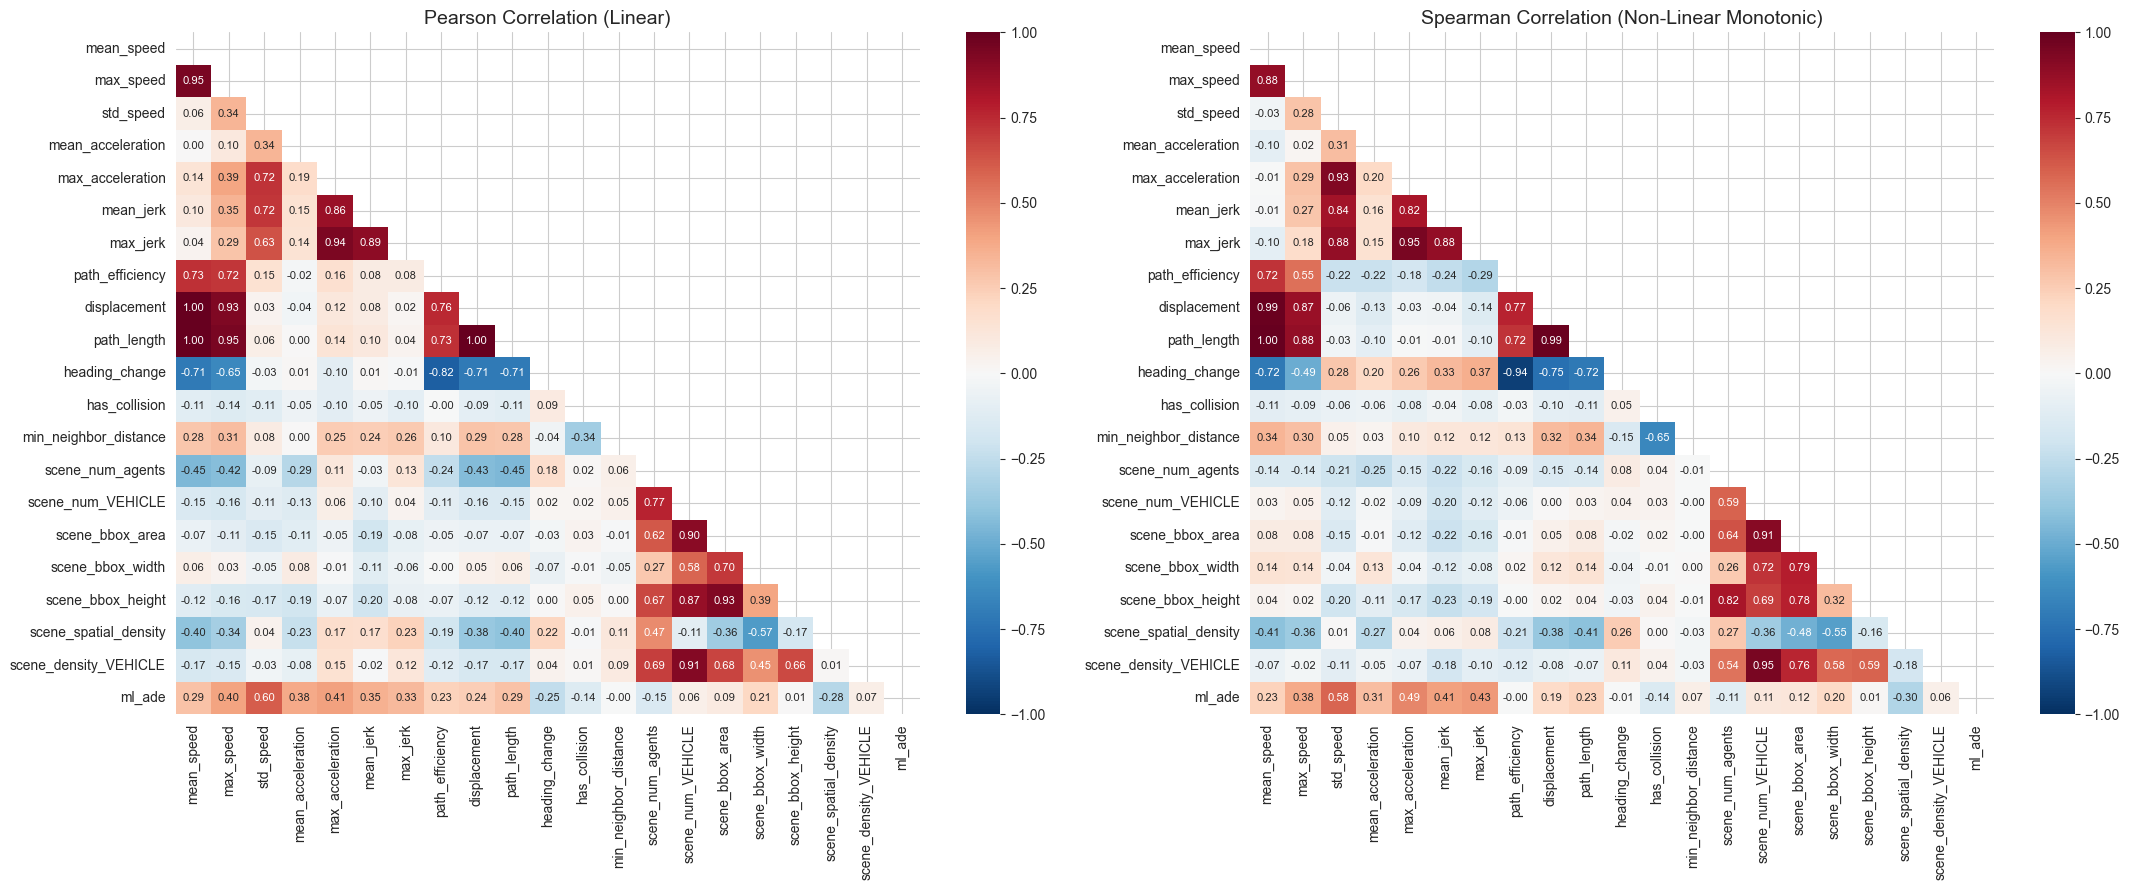

In [10]:
# Pearson and Spearman correlation matrices
all_numeric = numerical_cols + [target_col]
pearson_corr = df[all_numeric].corr(method="pearson")
spearman_corr = df[all_numeric].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Pearson heatmap
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 8})
axes[0].set_title("Pearson Correlation (Linear)", fontsize=14)

# Spearman heatmap
mask2 = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask2, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=axes[1], annot_kws={"size": 8})
axes[1].set_title("Spearman Correlation (Non-Linear Monotonic)", fontsize=14)

plt.tight_layout()
plt.savefig(SAVE_DIR / "correlation_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Compare Pearson vs Spearman correlations with the target
corr_comparison = pd.DataFrame({
    "Feature": numerical_cols,
    "Pearson (with target)": [pearson_corr.loc[c, target_col] for c in numerical_cols],
    "Spearman (with target)": [spearman_corr.loc[c, target_col] for c in numerical_cols],
})
corr_comparison["Difference (|P - S|)"] = abs(
    corr_comparison["Pearson (with target)"] - corr_comparison["Spearman (with target)"]
)
corr_comparison = corr_comparison.sort_values("Pearson (with target)", ascending=False, key=abs).reset_index(drop=True)

print("Pearson vs Spearman Correlation with Target:")
print("(Large differences suggest non-linear relationships)")
corr_comparison

Pearson vs Spearman Correlation with Target:
(Large differences suggest non-linear relationships)


,Feature,Pearson (with target),Spearman (with target),Difference (|P - S|)
0,std_speed,0.604552,0.578428,0.026124
1,max_acceleration,0.408524,0.492077,0.083553
2,max_speed,0.404844,0.377828,0.027016
3,mean_acceleration,0.379868,0.305757,0.074111
4,mean_jerk,0.352247,0.409452,0.057205
5,max_jerk,0.326687,0.433106,0.106419
6,mean_speed,0.292345,0.232928,0.059417
7,path_length,0.292345,0.232929,0.059416
8,scene_spatial_density,-0.284785,-0.302386,0.017601
9,heading_change,-0.246151,-0.005637,0.240514


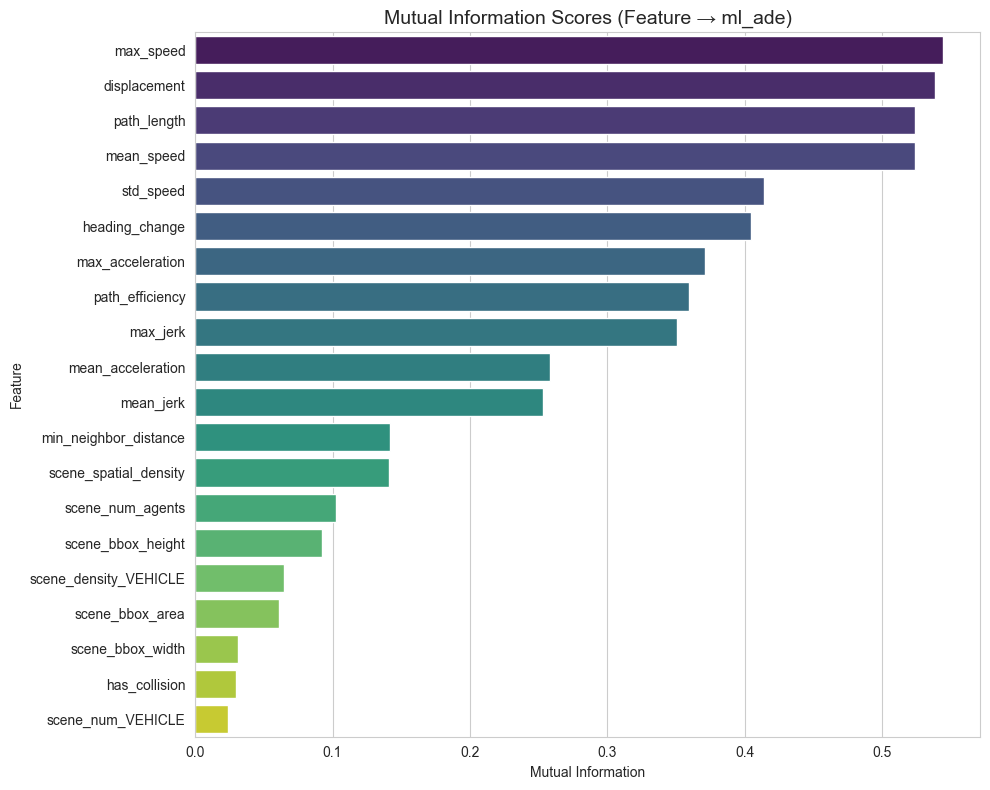

,Feature,Mutual Information
0,max_speed,0.544170
1,displacement,0.538797
2,path_length,0.524372
3,mean_speed,0.524242
4,std_speed,0.413781
5,heading_change,0.405001
6,max_acceleration,0.371108
7,path_efficiency,0.359630
8,max_jerk,0.350978
9,mean_acceleration,0.258314


In [12]:
# Mutual Information scores (detects non-linear dependencies)
X_for_mi = df[numerical_cols].dropna()
y_for_mi = df.loc[X_for_mi.index, target_col]

mi_scores = mutual_info_regression(X_for_mi, y_for_mi, random_state=42)
mi_df = pd.DataFrame({
    "Feature": numerical_cols,
    "Mutual Information": mi_scores
}).sort_values("Mutual Information", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(numerical_cols) * 0.4)))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="viridis", ax=ax)
ax.set_title(f"Mutual Information Scores (Feature → {target_col})", fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_DIR / "mutual_information_scores.png", dpi=150, bbox_inches="tight")
plt.show()

mi_df

## 6. Remove Highly Correlated Features
**Purpose:** Reduce redundant predictors while preserving the feature from each correlated pair that is more informative about the target.<br>
**Inputs:** numerical feature list, target column, and the correlation threshold.<br>
**Outputs:** `selected_features`, `removed_features`, and a documented rationale for each removed feature.<br>
**How to Verify:** confirm every removed feature belongs to a pair above the threshold and that the retained feature has equal or stronger absolute target correlation.


In [13]:
def remove_highly_correlated(df, feature_cols, target_col, threshold=0.85):
    """
    Remove one feature from each pair of highly correlated features,
    keeping the one with higher absolute correlation with the target.
    
    Returns:
        selected_features: list of features to keep
        removed_features: list of removed features with reasons
    """
    # Use absolute Spearman correlation because both strong positive and strong negative
    # monotonic relationships represent redundancy for the downstream models.
    corr_matrix = df[feature_cols].corr(method="spearman").abs()
    target_corr = df[feature_cols].corrwith(df[target_col], method = "spearman").abs()
    
    removed = set()
    removal_log = []
    
    for i in range(len(feature_cols)):
        for j in range(i + 1, len(feature_cols)):
            feat_i = feature_cols[i]
            feat_j = feature_cols[j]
            
            if feat_i in removed or feat_j in removed:
                continue
                
            if corr_matrix.loc[feat_i, feat_j] >= threshold:
                # Keep the feature that is at least as informative about the target.
                if target_corr[feat_i] >= target_corr[feat_j]:
                    removed.add(feat_j)
                    removal_log.append({
                        "Removed": feat_j,
                        "Kept": feat_i,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Spearman with {target_col} (removed)": target_corr[feat_j],
                        f"Spearman with {target_col} (kept)": target_corr[feat_i],
                    })
                else:
                    removed.add(feat_i)
                    removal_log.append({
                        "Removed": feat_i,
                        "Kept": feat_j,
                        "Inter-correlation": corr_matrix.loc[feat_i, feat_j],
                        f"Spearman with {target_col} (removed)": target_corr[feat_i],
                        f"Spearman with {target_col} (kept)": target_corr[feat_j],
                    })
    
    selected_features = [f for f in feature_cols if f not in removed]
    return selected_features, removal_log


# Apply correlation-based feature removal
CORR_THRESHOLD = 0.85
selected_features, removal_log = remove_highly_correlated(
    df, numerical_cols, target_col, threshold=CORR_THRESHOLD
)

print(f"Correlation threshold: {CORR_THRESHOLD}")
print(f"Original features: {len(numerical_cols)}")
print(f"Features after removal: {len(selected_features)}")
print(f"Features removed: {len(numerical_cols) - len(selected_features)}")

if removal_log:
    print(f"\nRemoval details:")
    removal_df = pd.DataFrame(removal_log)
    display(removal_df)
else:
    print("\nNo features exceeded the correlation threshold.")

print(f"\nSelected features: {selected_features}")


Correlation threshold: 0.85
Original features: 20
Features after removal: 13
Features removed: 7

Removal details:


,Removed,Kept,Inter-correlation,Spearman with ml_ade (removed),Spearman with ml_ade (kept)
0,mean_speed,max_speed,0.882674,0.232928,0.377828
1,displacement,max_speed,0.865581,0.192336,0.377828
2,path_length,max_speed,0.882674,0.232929,0.377828
3,max_acceleration,std_speed,0.925920,0.492077,0.578428
4,max_jerk,std_speed,0.882225,0.433106,0.578428
5,path_efficiency,heading_change,0.938317,0.000891,0.005637
6,scene_num_VEHICLE,scene_bbox_area,0.908765,0.112755,0.118190



Selected features: ['max_speed', 'std_speed', 'mean_acceleration', 'mean_jerk', 'heading_change', 'has_collision', 'min_neighbor_distance', 'scene_num_agents', 'scene_bbox_area', 'scene_bbox_width', 'scene_bbox_height', 'scene_spatial_density', 'scene_density_VEHICLE']


## 7. Log Transform Target (If Right Skewed)
**Purpose:** Decide whether the target should be exported on a log scale and produce the final modelling table on the chosen feature/target contract.<br>
**Inputs:** target skewness estimate, selected features, and the cleaned dataframe.<br>
**Outputs:** transformed target column (when needed), final `model_df`, feature matrix/vector, and the exported prepared CSV.<br>
**How to Verify:** confirm the logged target is created only when skewness justifies it, the final row count reflects a single `dropna` after feature selection, and the exported CSV contains the expected feature plus target columns.


Target skewness: 1.4600
Apply log transformation: True


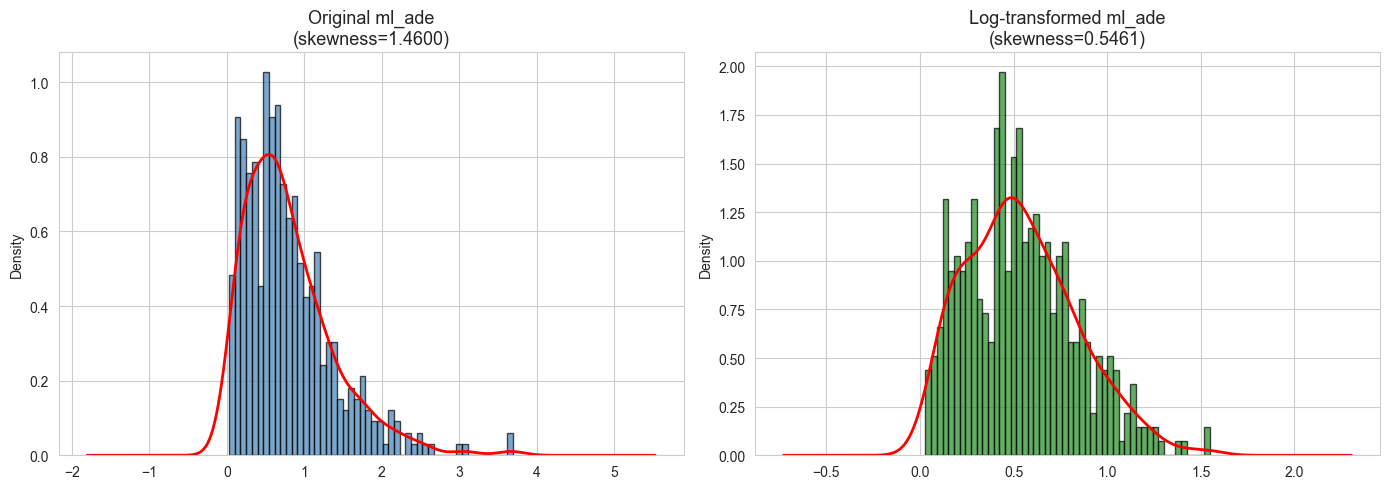


Log-transformed target column: 'ml_ade_log'


In [14]:
# Decide on log transformation
LOG_TRANSFORM = target_skewness > 1.0
print(f"Target skewness: {target_skewness:.4f}")
print(f"Apply log transformation: {LOG_TRANSFORM}")

if LOG_TRANSFORM:
    # Keep a copy of the raw target so the before/after plots can verify that the
    # transformation improved skewness without losing access to the original values.
    y_original = df[target_col].copy()
    # Use log1p for numerical stability (handles values near zero)
    df[f"{target_col}_log"] = np.log1p(df[target_col])
    y_transformed_col = f"{target_col}_log"
    
    # Plot before and after
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(y_original.dropna(), bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="black")
    y_original.dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
    axes[0].set_title(f"Original {target_col}\n(skewness={skew(y_original.dropna()):.4f})", fontsize=13)
    
    y_log = df[y_transformed_col]
    axes[1].hist(y_log.dropna(), bins=50, density=True, alpha=0.7, color="forestgreen", edgecolor="black")
    y_log.dropna().plot.kde(ax=axes[1], color="red", linewidth=2)
    axes[1].set_title(f"Log-transformed {target_col}\n(skewness={skew(y_log.dropna()):.4f})", fontsize=13)
    
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f"target_log_transform_{target_col}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\nLog-transformed target column: '{y_transformed_col}'")
else:
    y_transformed_col = target_col
    print("No transformation applied — target is approximately symmetric.")


In [15]:
# Perform the final `dropna` only after feature selection and target transformation are
# fixed so the exported dataset matches the contract used by downstream modelling notebooks.
# Prepare the data (drop rows with NaN in selected features or target)
model_df = df[selected_features + model_setting_cols + [y_transformed_col]].dropna().copy()
print(f"Rows available for modeling: {len(model_df)} (dropped {len(df) - len(model_df)} rows with NaN)")

X = model_df[selected_features].values
y = model_df[y_transformed_col].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Rows available for modeling: 451 (dropped 0 rows with NaN)

Feature matrix shape: (451, 13)
Target vector shape: (451,)


In [16]:
# Export exactly the modelling columns that downstream notebooks will load; nothing else
# should be required for them to reconstruct the training matrix and target vector.
# Export prepared dataset into results/interpretable_model/prepared_data
EXPORT_DIR = Path("../../results/interpretable_model/prepared_data") / RUN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = EXPORT_DIR / f"prepared_data_{target_col}.csv"
model_df.to_csv(EXPORT_PATH, index=False)
print(f"\nPrepared dataset (run-scoped) exported to: {EXPORT_PATH}")



Prepared dataset (run-scoped) exported to: ../../results/interpretable_model/prepared_data/nusc_mini_debug_tpp-11_Mar_2026_15_29_02/prepared_data_ml_ade.csv
